CDC veri setleri her yıl güncellendiği için bazı değişken isimlerinde (örneğin ALCDAY) versiyon farklılıkları olabilmektedir. Tüm veri setini belleğe yüklemeden önce, nrows=0 parametresi ile sadece başlıkları okuyarak hedef kolonlarımızın 2024 yılındaki güncel isimlendirmelerini tespit ettik.

In [16]:
import pandas as pd

dosya_yolu = r"C:\Users\nefsa\Desktop\Ruh Sağlığı ve Yaşam Tarzı Korelasyonu proje-3\brfss_survey_data_2024.csv"

# nrows=0 parametresi, verileri değil sadece kolon isimlerini okur 
df_cols = pd.read_csv(dosya_yolu, nrows=0)
tum_kolonlar = df_cols.columns.tolist()

# Büyük/küçük harf duyarlılığını kaldırmak için upper() kullanıyoruz
print("İçinde 'MENT' geçen kolonlar:", [c for c in tum_kolonlar if 'MENT' in c.upper()])
print("İçinde 'ALC' geçen kolonlar:", [c for c in tum_kolonlar if 'ALC' in c.upper()])
print("İçinde 'SMOK' geçen kolonlar:", [c for c in tum_kolonlar if 'SMOK' in c.upper()])
print("İçinde 'EXER' geçen kolonlar:", [c for c in tum_kolonlar if 'EXER' in c.upper()])

İçinde 'MENT' geçen kolonlar: ['MENTHLTH', 'MENTCIGS', 'MENTECIG', '_MENT14D']
İçinde 'ALC' geçen kolonlar: ['ALCDAY4', '_DUALCOR']
İçinde 'SMOK' geçen kolonlar: ['SMOKE100', 'SMOKDAY2', 'MARJSMOK', '_SMOKER3', '_RFSMOK3']
İçinde 'EXER' geçen kolonlar: ['EXERANY2', 'ARTHEXER']


In [17]:
import pandas as pd
import numpy as np

dosya_yolu = r"C:\Users\nefsa\Desktop\Ruh Sağlığı ve Yaşam Tarzı Korelasyonu proje-3\brfss_survey_data_2024.csv"

secilen_kolonlar = ['MENTHLTH', 'ALCDAY4', 'SMOKE100', 'EXERANY2', 'EMTSUPRT', 'MARITAL']

print("Veri yükleniyor.")
df = pd.read_csv(dosya_yolu, usecols=secilen_kolonlar)
print("Veri başarıyla yüklendi!\n")

# VERİ TEMİZLEME 
# MENTHLTH: 88 kodu '0 gün' demektir. 77 ve 99 ise geçersizdir.
df['MENTHLTH'] = df['MENTHLTH'].replace(88, 0)
df['MENTHLTH'] = df['MENTHLTH'].replace([77, 99], np.nan)

# ALCDAY4: 777 ve 999 geçersiz (bilmiyorum/reddedildi)
df['ALCDAY4'] = df['ALCDAY4'].replace([777, 999], np.nan)

# SMOKE100 ve EXERANY2: 7 ve 9 geçersiz (bilmiyorum/reddedildi)
df['SMOKE100'] = df['SMOKE100'].replace([7, 9], np.nan)
df['EXERANY2'] = df['EXERANY2'].replace([7, 9], np.nan)

# EMTSUPRT: 7 ve 9 geçersiz (bilmiyorum/reddedildi)
df['EMTSUPRT'] = df['EMTSUPRT'].replace([7, 9], np.nan)

# MARITAL: 9 geçersiz (reddedildi)
df['MARITAL'] = df['MARITAL'].replace(9, np.nan)

print("Temizlik sonrası eksik (NaN) veri dağılımı:")
print(df.isnull().sum())

Veri yükleniyor.
Veri başarıyla yüklendi!

Temizlik sonrası eksik (NaN) veri dağılımı:
MENTHLTH      8156
EXERANY2      1315
MARITAL       4222
SMOKE100     31472
ALCDAY4      43777
EMTSUPRT    257046
dtype: int64


In [18]:
from sklearn.impute import KNNImputer

print("KNN İmputasyonu başlıyor.")

# KNN Imputer nesnesini oluşturuyoruz. n_neighbors=5 standart bir başlangıçtır.
# Yani eksik bir veriyi doldurmak için en çok benzeyen 5 kişiye bakacak.
imputer = KNNImputer(n_neighbors=5)

# İmputasyon işlemini (fit_transform) uyguluyoruz.
# Not: Bu işlem bize NumPy dizisi (array) döndürür, onu tekrar DataFrame'e çevireceğiz.
df_imputed = pd.DataFrame(imputer.fit_transform(df), columns=df.columns)

print("KNN İmputasyonu tamamlandı!\n")

print("Yeni eksik (NaN) veri dağılımı:")
print(df_imputed.isnull().sum())

KNN İmputasyonu başlıyor.
KNN İmputasyonu tamamlandı!

Yeni eksik (NaN) veri dağılımı:
MENTHLTH    0
EXERANY2    0
MARITAL     0
SMOKE100    0
ALCDAY4     0
EMTSUPRT    0
dtype: int64


Veri bütünlüğü KNN ile sağlandıktan sonra, hedef değişkenimiz olan ruh sağlığı ile yaşam tarzı faktörleri arasındaki doğrusal ilişkiyi tespit etmek için Keşifsel Veri Analizi (EDA) uygulanmış ve korelasyon matrisi çıkarılmıştır.

Keşifsel Veri Analizi (EDA) Başlıyor...

Veri Setinin İstatistiksel Özeti:
            MENTHLTH       EXERANY2        MARITAL       SMOKE100  \
count  457670.000000  457670.000000  457670.000000  457670.000000   
mean        4.416199       1.233141       2.397177       1.603744   
std         8.305502       0.422286       1.723298       0.474890   
min         0.000000       1.000000       1.000000       1.000000   
25%         0.000000       1.000000       1.000000       1.000000   
50%         0.000000       1.000000       1.000000       2.000000   
75%         5.000000       1.000000       4.000000       2.000000   
max        30.000000       2.000000       6.000000       2.000000   

             ALCDAY4       EMTSUPRT  
count  457670.000000  457670.000000  
mean      529.008431       1.944596  
std       343.619386       0.853519  
min       100.000000       1.000000  
25%       202.000000       1.200000  
50%       574.000000       2.000000  
75%       888.000000       2.400000  

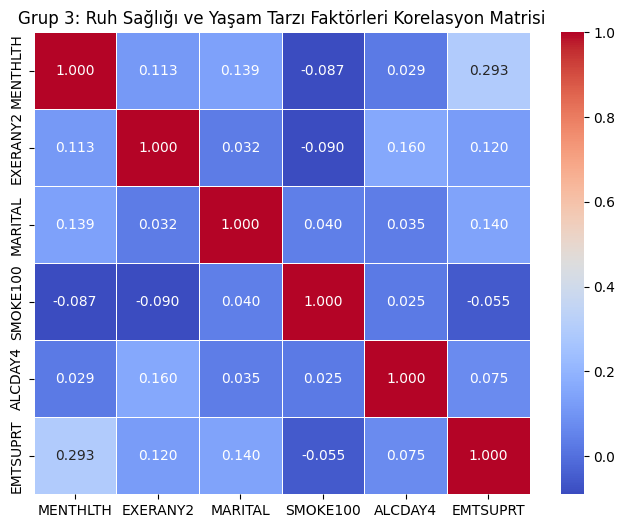

In [19]:
import seaborn as sns
import matplotlib.pyplot as plt

print("Keşifsel Veri Analizi (EDA) Başlıyor...\n")

# 1. Temel İstatistiksel Özet
print("Veri Setinin İstatistiksel Özeti:")
print(df_imputed.describe())

# 2. Korelasyon Matrisinin Hesaplanması
korelasyon_matrisi = df_imputed.corr()

print("\nDeğişkenlerin Ruh Sağlığı (MENTHLTH) ile Korelasyon Katsayıları:")
print(korelasyon_matrisi['MENTHLTH'])

# 3. Görselleştirme: Isı Haritası (Heatmap)
plt.figure(figsize=(8, 6))
sns.heatmap(korelasyon_matrisi, annot=True, cmap='coolwarm', fmt=".3f", linewidths=0.5)
plt.title('Grup 3: Ruh Sağlığı ve Yaşam Tarzı Faktörleri Korelasyon Matrisi')
plt.show()

Isı haritası ve istatistiksel özet incelendiğinde, ALCDAY4 değişkenindeki maksimum değerin anket kodlama yapısından (0 gün = 888) kaynaklandığı tespit edilmiştir. Modelin öğrenme katsayılarının (Theta) sapmaması için bu anomali düzeltilip regresyon aşamasına geçilmiştir.

In [20]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

print("Gözden kaçan 888 (0 gün) anomalisini düzeltiyoruz.")
# 888 kodunu gerçek anlamı olan 0 gün ile değiştiriyoruz
df_imputed['ALCDAY4'] = df_imputed['ALCDAY4'].replace(888, 0)

# Veriyi Eğitim (%80) ve Test (%20) olarak ayırma
print("\nVeri Eğitim ve Test setlerine ayrılıyor...")
# X: Bağımsız Değişkenler (Öznitelikler)
X = df_imputed[['EXERANY2', 'SMOKE100', 'ALCDAY4', 'EMTSUPRT', 'MARITAL']]  
# y: Bağımlı Değişken (Hedef: Kötü ruh sağlığı gün sayısı)
y = df_imputed['MENTHLTH'] 

# Modelin daha önce görmediği veri üzerinde test edilebilmesi için bölme işlemi
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Lineer Regresyon Modelinin Kurulması ve Testi
print("Lineer Regresyon Modeli eğitiliyor (Scikit-Learn)...\n")
model = LinearRegression()
model.fit(X_train, y_train) # Model parametreleri öğreniyor (Theta değerleri)

# Test seti üzerinde tahmin yapma
tahminler = model.predict(X_test)

# MSE (Ortalama Kare Hata) metriği ile başarıyı ölçme
mse = mean_squared_error(y_test, tahminler)
r2 = r2_score(y_test, tahminler)

print(" MODEL ÇIKTILARI VE PERFORMANS ")
print(f"Model Sabiti (Intercept - Theta 0): {model.intercept_:.4f}")
print(f"Model Katsayıları (Egzersiz, Sigara, Alkol, Duygusal Destek, Medeni Durum): {model.coef_}")
print(f"Test Seti MSE (Ortalama Kare Hata): {mse:.4f}")
print(f"Test Seti R-Kare Skoru: {r2:.4f}")

Gözden kaçan 888 (0 gün) anomalisini düzeltiyoruz.

Veri Eğitim ve Test setlerine ayrılıyor...
Lineer Regresyon Modeli eğitiliyor (Scikit-Learn)...

 MODEL ÇIKTILARI VE PERFORMANS 
Model Sabiti (Intercept - Theta 0): -1.7449
Model Katsayıları (Egzersiz, Sigara, Alkol, Duygusal Destek, Medeni Durum): [ 1.41843848e+00 -1.22375582e+00  1.01521371e-03  2.60286412e+00
  4.91213383e-01]
Test Seti MSE (Ortalama Kare Hata): 61.5351
Test Seti R-Kare Skoru: 0.1079
